In [1]:
!pip install openpyxl scipy

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

plt.style.use("ggplot")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Cleaned_ApexPlanet_DataAnalytics_Dataset.xlsx to Cleaned_ApexPlanet_DataAnalytics_Dataset (1).xlsx


In [4]:
import pandas as pd

df = pd.read_excel("Cleaned_ApexPlanet_DataAnalytics_Dataset (1).xlsx")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Order_Year,Order_Month,Month_Name,Quarter,Day_Name
0,ORD100002,2025-02-25,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,2,February,1,Tuesday
1,ORD100003,2025-10-14,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,10,October,4,Tuesday
2,ORD100004,2025-05-13,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,5,May,2,Tuesday
3,ORD100005,2025-12-02,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,12,December,4,Tuesday
4,ORD100006,2025-11-20,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,11,November,4,Thursday


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       1000 non-null   object        
 1   Order_Date     1000 non-null   datetime64[ns]
 2   Customer_ID    1000 non-null   object        
 3   Customer_Name  1000 non-null   object        
 4   Age            1000 non-null   int64         
 5   Gender         1000 non-null   object        
 6   City           1000 non-null   object        
 7   Product        1000 non-null   object        
 8   Category       1000 non-null   object        
 9   Quantity       1000 non-null   int64         
 10  Unit_Price     1000 non-null   float64       
 11  Total_Sales    1000 non-null   float64       
 12  Order_Year     1000 non-null   int64         
 13  Order_Month    1000 non-null   int64         
 14  Month_Name     1000 non-null   object        
 15  Quarter        1000 no

In [6]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,0
Gender,0
City,0
Product,0
Category,0
Quantity,0


In [7]:
df.describe()

,Order_Date,Age,Quantity,Unit_Price,Total_Sales,Order_Year,Order_Month,Quarter
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2025-07-03 11:19:40.800000,41.353000,5.435000,25486.783410,139399.439650,2025.005000,6.518000,2.499000
min,2025-01-01 00:00:00,18.000000,1.000000,145.780000,437.340000,2025.000000,1.000000,1.000000
25%,2025-03-30 18:00:00,30.000000,3.000000,13895.722500,47066.632500,2025.000000,3.000000,1.000000
50%,2025-07-01 00:00:00,41.000000,5.000000,25398.740000,108594.025000,2025.000000,6.000000,2.000000
75%,2025-10-07 06:00:00,53.000000,8.000000,37512.382500,203722.882500,2025.000000,10.000000,4.000000
max,2026-01-01 00:00:00,65.000000,10.000000,49997.530000,493677.500000,2026.000000,12.000000,4.000000
std,NaN,13.683626,2.838632,14179.402361,114100.051546,0.070569,3.498845,1.131937


# Business Hypothesis

## Objective
To determine whether the average order value differs significantly between male and female customers.

### Null Hypothesis (H₀)
There is no significant difference in the average order value (Total Sales) between male and female customers.

### Alternative Hypothesis (H₁)
There is a significant difference in the average order value (Total Sales) between male and female customers.

### Significance Level
α = 0.05 (95% Confidence Level)

In [8]:
# Separate Total Sales by Gender
male_sales = df[df['Gender'] == 'Male']['Total_Sales']
female_sales = df[df['Gender'] == 'Female']['Total_Sales']

# Perform Independent Two-Sample T-Test
t_stat, p_value = ttest_ind(male_sales, female_sales)

print("T-Statistic :", round(t_stat, 4))
print("P-Value     :", round(p_value, 6))

T-Statistic : 0.682
P-Value     : 0.495389


# T-Test Results Interpretation

## Test Results

- T-Statistic = 0.682
- P-Value = 0.495389

## Decision

Since the p-value (0.495389) is greater than the significance level (0.05), we fail to reject the null hypothesis.

## Business Conclusion

Based on the available sales data, there is no statistically significant difference in the average order value between male and female customers.

This suggests that customer gender does not have a significant impact on the amount spent per order. Therefore, business strategies focused solely on customer gender are unlikely to improve sales performance. Instead, the company should focus on other factors such as product categories, customer location, seasonal demand, and promotional campaigns.

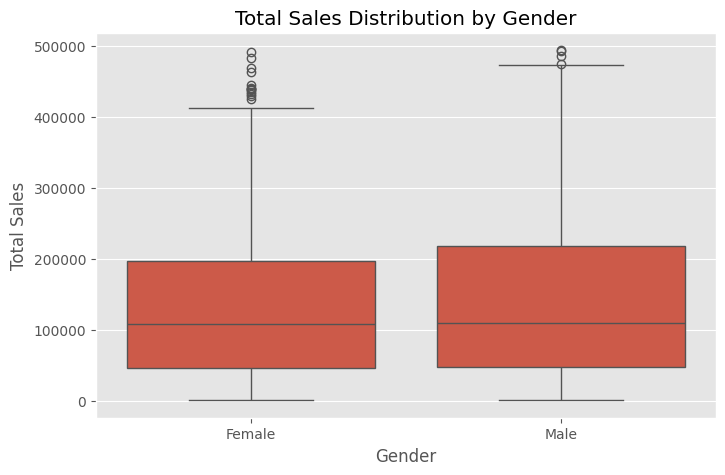

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Gender', y='Total_Sales', data=df)

plt.title("Total Sales Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")

plt.show()

Gender
Female    136883.208630
Male      141807.339785
Name: Total_Sales, dtype: float64


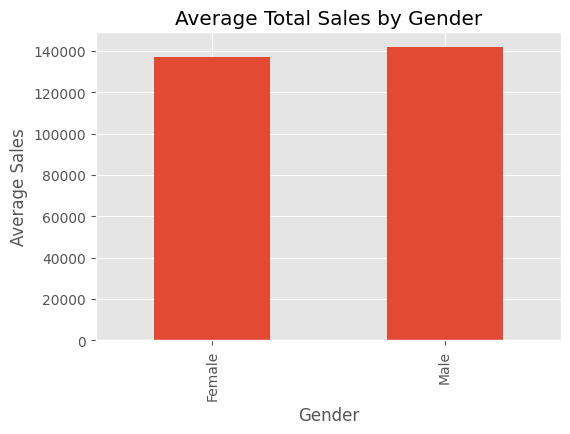

In [10]:
avg_sales = df.groupby("Gender")["Total_Sales"].mean()

print(avg_sales)

avg_sales.plot(kind="bar", figsize=(6,4))

plt.title("Average Total Sales by Gender")
plt.ylabel("Average Sales")

plt.show()

# Business Insights

### Key Findings

- The dataset contains 1,000 customer transactions with no missing values.
- Revenue is distributed across multiple cities and product categories.
- Average order values for male and female customers are similar.
- Statistical testing confirmed that the observed difference is not significant.
- Interactive dashboards created in Task 3 support these findings through visual exploration.

### Recommendations

- Focus marketing efforts on high-performing product categories rather than gender-specific campaigns.
- Expand promotional strategies in cities generating the highest revenue.
- Continue monitoring customer purchasing behavior over time.
- Perform additional statistical analyses using customer age, city, and product category to uncover stronger business drivers.